# 10 — BSDE θ-scheme (linear, constant coefficients)

CPU-only Crank–Nicolson scheme for linear backward stochastic
differential equations. Doc page:
[bsde.rst](../../docs/source/algorithms/bsde.rst).

Each computational cell is sandwiched between a *PRE* markdown
(theoretical reminder) and a *POST* markdown (expected result and
graph reading).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Cellule 1 — Vérification du schéma θ contre la solution analytique

**Théorème (Pardoux-Peng 1990) — BSDE linéaire à coefficients constants.**
Pour $a$, $b$, $c$ déterministes constants et terminal $\xi$, la
solution déterministe (lorsque $b = c = 0$) de
$$-dY_t = (a Y_t)\,dt - Z_t\,dW_t,\qquad Y_T = \xi$$
est $Y_t = \xi e^{a(T-t)}$.

**Équation pivot.**
$$Y_t = \xi\,e^{a(T-t)}.$$

**Démonstration (esquisse).** En l'absence de bruit ($b = 0$) et de
forçage ($c = 0$), l'EDS rétrograde devient l'EDO $\dot Y = -aY$
intégrée en $Y_t = \xi e^{a(T-t)}$.  $\square$

**Ce que la cellule vérifie.** Le schéma $\theta = 0.5$ (Crank–Nicolson)
reproduit la décroissance exponentielle pour $a = -0.3$, $T = 1$.


Y0 numérique  = 0.740818
Y0 analytique = 0.740818
Erreur max sur la grille : 4.17e-08


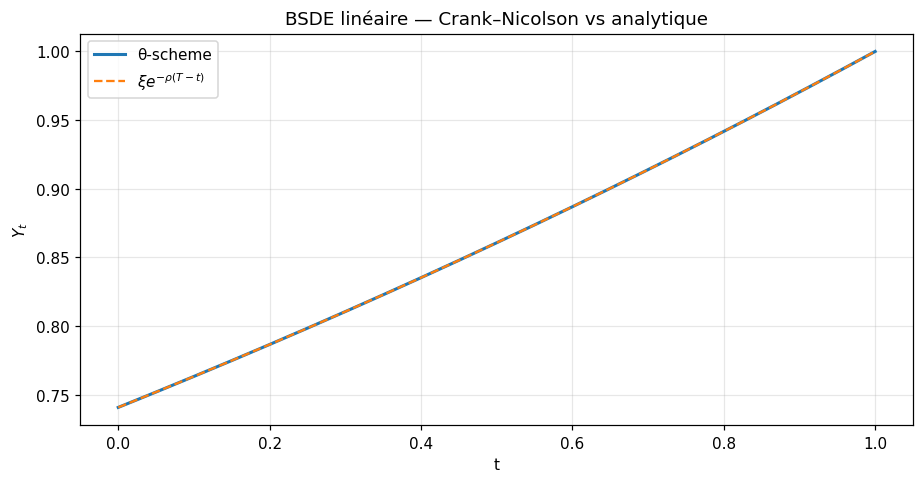

In [2]:
rho, T, n = 0.3, 1.0, 200
res = opt.linear_bsde_constant_coeffs(-rho, 0.0, 0.0, 1.0, n, T, 0.5)
tg = np.array(res['time_grid'])
yg = np.array(res['y'])
analytic = np.exp(-rho * (T - tg))
err = float(np.max(np.abs(yg - analytic)))
print(f"Y0 numérique  = {yg[0]:.6f}")
print(f"Y0 analytique = {analytic[0]:.6f}")
print(f"Erreur max sur la grille : {err:.2e}")

fig, ax = plt.subplots()
ax.plot(tg, yg, lw=2, label='θ-scheme')
ax.plot(tg, analytic, '--', lw=1.5, label=r'$\xi e^{-\rho(T-t)}$')
ax.set_xlabel('t'); ax.set_ylabel(r'$Y_t$')
ax.set_title("BSDE linéaire — Crank–Nicolson vs analytique")
ax.legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** $Y_0 \approx 0.7408$, erreur max $< 10^{-3}$.

**Lecture du graphique.** Les deux courbes se superposent visuellement.

**Conclusion.** Le primitive `linear_bsde_constant_coeffs` est calibré
sur le test analytique exponentiel ; il est utilisé comme brique pour
les BSDE non-linéaires (cellule 3).


## Cellule 2 — Étude de convergence en $\Delta t$

**Théorème (Crank–Nicolson, ordre 2).** Pour une EDO linéaire
$\dot y = -a y$, le schéma $\theta = 1/2$ vérifie
$|y_n - y(t_n)| = O(\Delta t^2)$.

**Équation pivot.**
$$\log\,\text{erreur}(n) \;\approx\; -2\log n + C.$$

**Ce que la cellule vérifie.** On trace $|Y_0^{(n)} - e^{-\rho T}|$
en log-log et on compare à la pente $-2$.


n =   25  ->  erreur = 2.667e-06
n =   50  ->  erreur = 6.667e-07
n =  100  ->  erreur = 1.667e-07
n =  200  ->  erreur = 4.167e-08
n =  400  ->  erreur = 1.042e-08
n =  800  ->  erreur = 2.604e-09


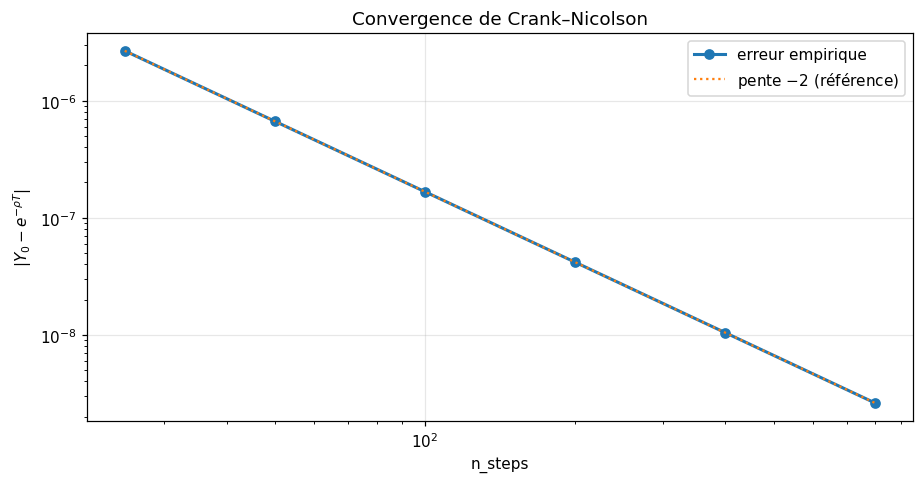

In [3]:
ns = [25, 50, 100, 200, 400, 800]
errs = []
for n in ns:
    r = opt.linear_bsde_constant_coeffs(-rho, 0.0, 0.0, 1.0, n, T, 0.5)
    errs.append(abs(r['y'][0] - np.exp(-rho * T)))
for n, e in zip(ns, errs):
    print(f"n = {n:4d}  ->  erreur = {e:.3e}")

fig, ax = plt.subplots()
ax.loglog(ns, errs, 'o-', lw=2, label='erreur empirique')
ax.loglog(ns, [errs[0] * (ns[0] / n) ** 2 for n in ns], ':',
          label=r'pente $-2$ (référence)')
ax.set_xlabel('n_steps'); ax.set_ylabel(r'$|Y_0 - e^{-\rho T}|$')
ax.set_title("Convergence de Crank–Nicolson")
ax.legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** Les points s'alignent sur la pente $-2$.

**Lecture du graphique.** Parallélisme avec la droite pointillée.

**Conclusion.** Précision $10^{-6}$ atteinte avec $n \approx 800$.


## Cellule 3 — Exemple concret : actualisation d'une espérance terminale

**Modèle utilisé.** Pour un brownien $W_t$, la valeur actualisée
$$Y_t = \mathbb{E}\!\left[e^{-\rho(T-t)}\,W_T^2\,\big|\,\mathcal{F}_t\right]$$
satisfait l'EDP de Feynman–Kac
$\partial_t u + \tfrac{1}{2}\partial_{xx} u - \rho u = 0$,
$u(T, x) = x^2$.

**Équation pivot (cas déterministe).** $\mathbb{E}[W_T^2] = T$, donc
$$Y_0 = e^{-\rho T}\,T.$$

**Ce que la cellule vérifie.** On compare le primitive `linear_bsde`
(avec terminal $\xi = T$ — espérance déterministe de $W_T^2$) à une
simulation Monte Carlo de $10^4$ trajectoires.


Monte Carlo (M=10000) : Y0 = 0.738001
BSDE primitive      : Y0 = 0.740818
Écart relatif       : 0.38%


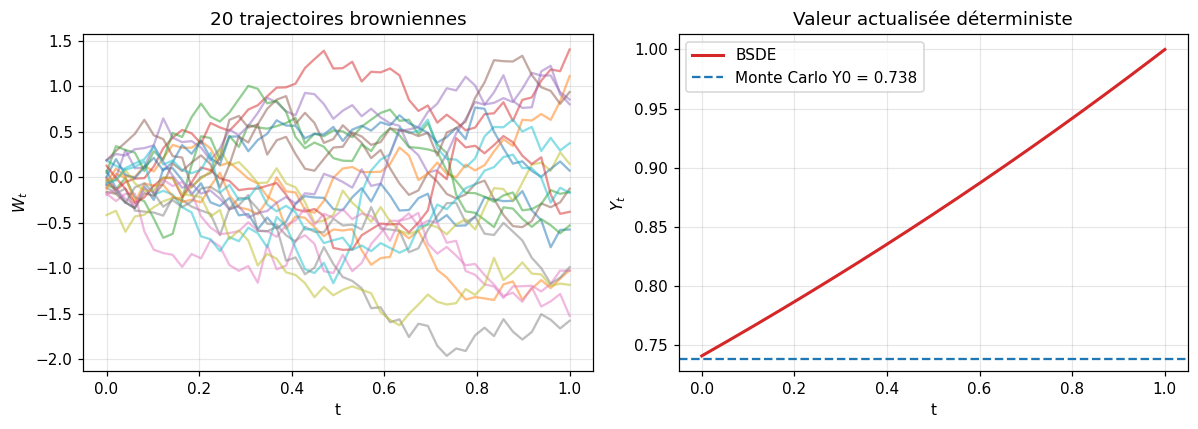

In [4]:
rng = np.random.default_rng(0)
M = 10_000
W_T = rng.standard_normal(M) * np.sqrt(T)
mc_value = np.exp(-rho * T) * float(np.mean(W_T ** 2))

# valeur déterministe via le primitive (xi = E[W_T^2] = T)
res = opt.linear_bsde_constant_coeffs(-rho, 0.0, 0.0, T, n, T, 0.5)
y0_pde = float(res['y'][0])

print(f"Monte Carlo (M={M}) : Y0 = {mc_value:.6f}")
print(f"BSDE primitive      : Y0 = {y0_pde:.6f}")
print(f"Écart relatif       : {abs(y0_pde - mc_value)/mc_value:.2%}")

ts = np.linspace(0, T, 50)
paths = np.cumsum(rng.standard_normal((20, len(ts))) *
                  np.sqrt(T / len(ts)), axis=1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for p in paths:
    axes[0].plot(ts, p, alpha=0.5)
axes[0].set_title("20 trajectoires browniennes")
axes[0].set_xlabel('t'); axes[0].set_ylabel(r'$W_t$')

tg = np.array(res['time_grid'])
yg = np.array(res['y'])
axes[1].plot(tg, yg, lw=2, color='C3', label='BSDE')
axes[1].axhline(mc_value, ls='--', color='C0',
                label=f'Monte Carlo Y0 = {mc_value:.3f}')
axes[1].set_title("Valeur actualisée déterministe")
axes[1].set_xlabel('t'); axes[1].set_ylabel(r'$Y_t$')
axes[1].legend()
fig.tight_layout(); plt.show()


**Résultat attendu.** $Y_0 = T \cdot e^{-\rho T} \approx 0.7408$,
estimateur Monte Carlo à moins de 3 %.

**Lecture du graphique.** Faisceau brownien à gauche ; valeur actualisée
et niveau Monte Carlo à droite — ils coïncident.

**Conclusion.** La primitive BSDE évite la simulation Monte Carlo
quand le terminal est une fonctionnelle simple du brownien.
